# Building an artificial pacemaker using a network of abstract neuron models

Adapted from [Aarushi Das' submission](https://https://github.com/aarushi-das2/moose2026hackathon) for the MOOSE Hackathon
The animation recording has been adapted from Gautham Dathatreyan

---
# Step 0: Setup

In [1]:
# If you need to install them, remove the '#' and run this line once:
# !pip install pymoose ipywidgets matplotlib numpy
# In Google Colab, also run:  from google.colab import output; output.enable_custom_widget_manager()

import numpy as np                      # arrays and maths
import matplotlib.pyplot as plt         # plotting
import ipywidgets as widgets            # sliders and the play button
from ipywidgets import interact, FloatSlider
from IPython.display import display
import io                               # (used by the movie in Step 3)
import moose                            # the simulator


def slider(start, lowest, highest, step):
    '''A slider that starts at `start` and moves between `lowest` and `highest`.'''
    return FloatSlider(value=start, min=lowest, max=highest, step=step, continuous_update=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.5/326.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 20.0 MB/s eta 0:00:00
   ━

---
# Step 1: LIF vs. AdExIF

You know the **LIF** neuron: it integrates its input, and when $V_m$ reaches threshold it **spikes and resets**. Every spike looks the same and, with a constant input, **the firing rate never changes**.

Real neurons often **adapt**: when driven by a constant input, they start firing fast, then **slow down**. This is called *spike-frequency adaptation*. The **AdExIF** neuron (*Adaptive Exponential Integrate-and-Fire*) adds two ingredients to the LIF:

1. **An exponential spike upstroke.** Instead of a hard threshold, the voltage runs away once it passes `thresh`: the term $\Delta_T\,e^{(V_m-\text{thresh})/\Delta_T}$ makes the spike rise quickly up to `vPeak`, where it is reset to `vReset`.
2. **An adaptation current $w$.** Each spike **adds** `b0` to $w$, and $w$ then **decays** with time constant `tauW`. The current $w$ flows *against* the input, so the more the neuron fires, the more it is held back:

$$\tau_m \frac{dV_m}{dt} = -(V_m - E_m) + \Delta_T e^{(V_m-\text{thresh})/\Delta_T} + R_m\,(I - w), \qquad \tau_w \frac{dw}{dt} = -w, \quad \text{spike: } w \to w + b_0$$

| | LIF | AdExIF |
|---|---|---|
| Spike | hard threshold, reset at `thresh` | exponential upstroke, reset at `vPeak` |
| Adaptation | none | current `w`: `b0` added per spike, decays with `tauW` |

### Code: two neurons
The code below builds each neuron type (all values in SI units). The passive part (`Rm`, `Cm`, `Em`) and `thresh`/`vReset` are **identical** in both, so any difference comes from the new ingredients. Both neurons get a **constant** (tonic) current of 3 nA via the `inject` field.

In [2]:
def make_lif(path, inject):
    n = moose.LIF(path)
    n.Rm = 100e6              # membrane resistance: 100 MOhm
    n.Cm = 1e-9               # membrane capacitance: 1 nF  (tau_m = 100 ms)
    n.Em = -65e-3             # rest: -65 mV
    n.initVm = -65e-3         # start at rest
    n.thresh = -45e-3         # spike threshold: -45 mV
    n.vReset = -60e-3         # reset voltage: -60 mV
    n.inject = inject         # constant input current (A)
    return n


def make_adexif(path, inject, b0, tauW):
    n = moose.AdExIF(path)
    n.Rm = 100e6              # same passive properties as the LIF ...
    n.Cm = 1e-9
    n.Em = -65e-3
    n.initVm = -65e-3
    n.thresh = -45e-3         # ... and the same threshold and reset
    n.vReset = -60e-3
    n.inject = inject
    n.deltaThresh = 10e-3     # sharpness of the spike upstroke: 10 mV
    n.vPeak = 30e-3           # the spike is cut and reset when Vm reaches +30 mV
    n.a0 = 0.0                # no subthreshold adaptation
    n.b0 = b0                 # adaptation current added at every spike (A)
    n.tauW = tauW             # decay time of the adaptation current (s)
    return n

`run_neuron` builds one neuron, records its voltage and its spike times, and runs 2 seconds. `compare` runs **three** versions and plots them: a LIF, an AdExIF **without** adaptation (`b0 = 0`) and an AdExIF **with** adaptation.

In [16]:
def run_neuron(kind, inject, b0=0.0, tauW=0.6, T=2.0):
    '''Simulate one neuron for T seconds. Returns time, Vm and the spike times.'''
    if moose.exists('/model'):
        moose.delete('/model')
    moose.Neutral('/model')

    if kind == 'LIF':
        neuron = make_lif('/model/neuron', inject)
    else:
        neuron = make_adexif('/model/neuron', inject, b0, tauW)

    vm_table = moose.Table('/model/vm')
    moose.connect(vm_table, 'requestOut', neuron, 'getVm')      # record Vm
    spike_table = moose.Table('/model/spikes')
    moose.connect(neuron, 'spikeOut', spike_table, 'input')     # record spike times

    moose.reinit()
    moose.start(T)

    vm = np.array(vm_table.vector)
    t = np.linspace(0, T, len(vm))
    return t, vm, np.array(spike_table.vector)


def compare(b0=500, tauW=0.6, inject=3.0):
    '''b0 in pA, tauW in s, inject in nA.'''
    runs = [('LIF',                          run_neuron('LIF',    inject * 1e-9)),
            ('AdExIF, no adaptation (b0=0)', run_neuron('AdExIF', inject * 1e-9, b0=0.0, tauW=tauW)),
            ('AdExIF with adaptation',       run_neuron('AdExIF', inject * 1e-9, b0=b0 * 1e-12, tauW=tauW))]

    fig = plt.figure(figsize=(11, 6))
    bins = np.arange(0, 2.0 + 0.1, 0.1)                          # 100 ms bins for the rate plot
    ax_rate = fig.add_subplot(1, 2, 2)
    for row, (label, (t, vm, spikes)) in enumerate(runs):
        ax = fig.add_subplot(3, 2, 2 * row + 1)                  # left column: Vm, first 0.4 s only
        ax.plot(t * 1000, vm * 1000, lw=0.8)
        ax.set_xlim(0, 400)
        ax.set_ylim(-70, 40)
        ax.set_title(label, fontsize=9)
        ax.set_ylabel('Vm (mV)')
        ax.axhline(-45, color='red', ls='--', label='threshold')
        ax.axhline(-65, color='green', ls=':', label='rest')
        counts, _ = np.histogram(spikes, bins)                   # spikes per bin
        ax_rate.plot(bins[:-1] + 0.05, counts / 0.1, 'o-', label=label)   # -> Hz
        print(f'{label:32s}: {len(spikes):4d} spikes in 2 s')
    ax.set_xlabel('time (ms)')
    ax_rate.set_xlabel('time (s)')
    ax_rate.set_ylabel('firing rate (Hz)')
    ax_rate.set_title('firing rate (100 ms bins)')
    ax_rate.legend(fontsize=8)
    ax_rate.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

LIF                             :  377 spikes in 2 s
AdExIF, no adaptation (b0=0)    :  112 spikes in 2 s
AdExIF with adaptation          :   22 spikes in 2 s


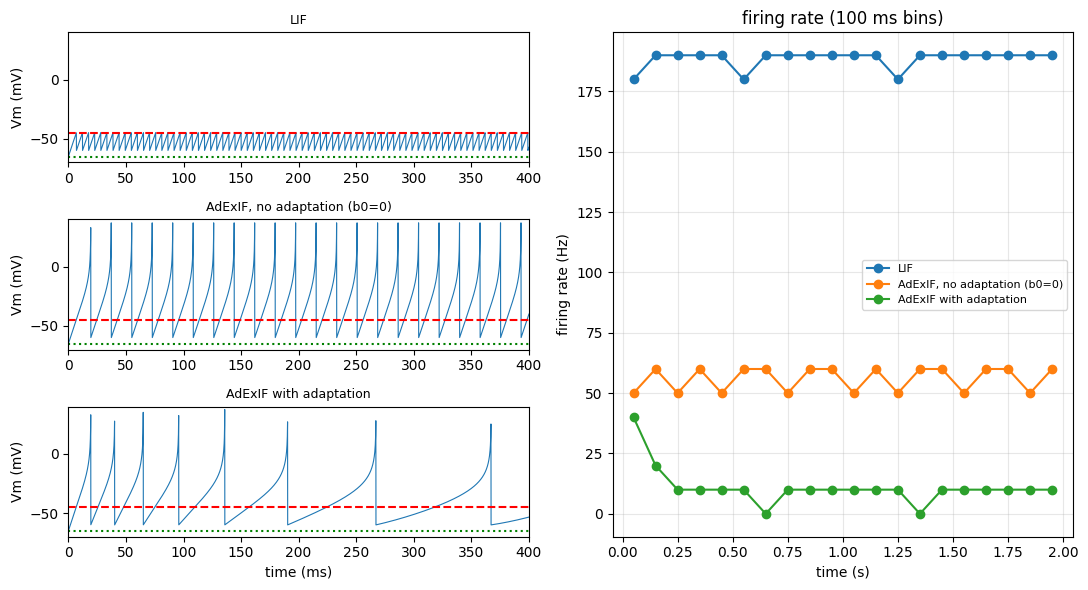

In [17]:
compare()

### 🧠 Question 1

Compare the **LIF** with the **AdExIF without adaptation** (top two traces and rate curves). (a) How do the spike shapes differ? (b) Their rates both stay constant over time, but they are not equal. Which neuron fires faster and why?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The LIF has no spike shape: $V_m$ climbs to the threshold (−45 mV) and is reset immediately. The AdExIF has an **exponential upstroke**: once $V_m$ passes threshold it takes off towards `vPeak` (+30 mV) before being reset.

(b) The **LIF fires faster** (about 190 Hz vs. about 55 Hz). It is reset from −45 mV, but the AdExIF is reset only after reaching +30 mV, so it has to climb about 75 mV more each cycle before it spikes. Both rates are **constant**, since without adaptation nothing changes from one spike to the next.

</details>

### 🧠 Question 2

Now look at the third neuron, the **AdExIF with adaptation** (`b0` = 500 pA). (a) How does its firing rate change over the 2 seconds? (b) Use the sliders below: what do `b0` and `tauW` each control? Try `b0` = 0, 200 and 800, then `tauW` = 0.2 and 1.5. (c) 🟡 *Optional:* why could slowly building up a brake like this be useful for a rhythm generator?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The rate **starts high (about 50 Hz) and falls steadily to about 10 Hz**: each spike adds to the adaptation current $w$, which holds the neuron back, so the interval between spikes grows (from about 20 ms to over 100 ms).

(b) **`b0` sets how strong the adaptation is**: with `b0` = 0 there is no adaptation (constant 55 Hz); a larger `b0` gives a faster, deeper drop (at 800 pA the rate falls to about 5 Hz). **`tauW` sets how long adaptation is remembered**: with a short `tauW` (0.2 s) $w$ decays quickly, so adaptation is weaker (final rate about 20 Hz); with a long `tauW` (1.5 s) $w$ piles up and the final rate is lower (about 5 Hz), but it takes longer to develop.

(c) Adaptation is a **slow, built-in negative feedback**: a neuron that has been active for a while gets tired and *lets go* by itself. A half-centre oscillator needs exactly such a slow process to end each phase (Step 2).

</details>

In [18]:
interact(compare, b0=slider(500, 0, 1000, 50), tauW=slider(0.6, 0.1, 2.0, 0.1), inject=slider(3.0, 1.0, 4.0, 0.5));

interactive(children=(FloatSlider(value=500.0, continuous_update=False, description='b0', max=1000.0, step=50.…

---
# Step 2: A half-centre oscillator

Many animals produce rhythms (walking, swimming, breathing, the heartbeat of the leech) with a very simple circuit: a **half-centre oscillator** (Brown, 1911). It has **two groups of neurons that inhibit each other** and **take turns** being active, with *no rhythmic input*: the drive is constant.

**Why does it work?** Reciprocal inhibition on its own does *not* oscillate: whichever group happens to fire first silences the other and keeps it silent forever (**winner-take-all**). The rhythm needs a **slow process that wears down the winner**. Here that process is the **spike-frequency adaptation** you just studied:

1. Pool A fires and (through its inhibitory neurons) silences pool B.
2. A keeps firing, so its adaptation current $w$ builds up and A **slows down**.
3. Meanwhile B is silent, so its own $w$ **decays**: B is recovering.
4. Eventually A is weak enough and B strong enough that B breaks through, inhibits A, and the roles swap. Repeat.

### The network
We keep it small: **50 neurons** in four populations (20 + 5 in each pool).

```
        constant 3 nA                          constant 3 nA
            |                                      |
            v                                      v
      ┌──── A_E ────┐                        ┌──── B_E ────┐
      │ 20 AdExIF   │                        │ 20 AdExIF   │
      └──┬───────▲──┘                        └──┬───────▲──┘
 excites │       │ inhibits                     │       │ inhibits
 (delta) │       │ (conductance)                │       │ (conductance)
         ▼       │                              ▼       │
      ┌───────────┴─┐ ───────────────────────────────── ┴──────┐
      │ A_I: 5 LIF  │  A_I inhibits B_E     B_I inhibits A_E     │ B_I: 5 LIF
      └─────────────┘                        └───────────────────┘
```
In words: **A_E excites A_I; A_I inhibits B_E** (and the same with A and B swapped).

* **No recurrent excitation (in the basic network):** E neurons do *not* excite each other. The only excitatory connections are E → I within a pool. You can switch on recurrent excitation (E → E) as an optional experiment (Question 9).
* **Dale's law:** excitatory neurons (E) only excite and inhibitory neurons (I) only inhibit. That is why mutual inhibition goes through the I neurons.
* **E neurons** are the adapting **AdExIF** neurons from Step 1, each with a constant 3 nA drive. **I neurons** are **LIF** neurons with *no* drive of their own; they fire only when excited by E neurons.
* **E → I synapses** are **delta synapses** (`SimpleSynHandler`, +4 mV jump). **I → E synapses** are **conductance synapses** (`SynChan`, reversal potential −80 mV): inhibition that is *bounded* (it can never push $V_m$ below −80 mV).
* **Connection probability `p`:** each possible connection exists with probability `p` (random, then fixed during the simulation).
* **Heterogeneity `hetero`:** no two neurons are identical. The drive, `b0` and `tauW` of every E neuron are multiplied by a random factor (a spread of 3 % by default).

**The knobs you will explore:** adaptation strength `b0`, inhibition strength `Gbar`, connection probability `p`, heterogeneity `hetero` (and optionally recurrent excitation `w_EE`).

### 🧠 Question 3

**Predict before you simulate.** Imagine the same network with **no adaptation** (`b0 = 0`): constant equal drive to both pools, reciprocal inhibition, nothing else. What do you expect to see?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

**Winner-take-all.** Both pools are driven equally, but tiny differences (here, the small random differences in drive and initial voltage) let one pool fire slightly earlier. Its inhibitory neurons then silence the other pool, which can never recover, because nothing weakens the winner. One pool fires continuously (about 55 Hz) and the other is silent forever. We will check this in Question 5.

</details>

**The neuron types.** E neurons are AdExIF, I neurons are LIF (the same ones as in Step 1). The little function `spread` creates the heterogeneity.

In [19]:
def spread(value, hetero):
    '''Heterogeneity: multiply `value` by a random factor around 1 (hetero = relative spread, 0.03 means 3 %).'''
    return value * (1 + hetero * np.random.randn())


def make_E(path, inject, b0, hetero):
    '''Excitatory neuron: AdExIF with a constant drive. Drive, b0 and tauW differ a little between neurons.'''
    n = moose.AdExIF(path)
    n.Rm, n.Cm, n.Em = 100e6, 1e-9, -65e-3
    n.thresh, n.vReset = -45e-3, -60e-3
    n.deltaThresh, n.vPeak = 10e-3, 30e-3
    n.a0 = 0.0
    n.b0 = spread(b0, hetero)                               # adaptation strength
    n.tauW = spread(0.6, hetero)                            # adaptation time constant
    n.inject = spread(inject, hetero)                       # constant drive
    n.initVm = -65e-3 + 5e-3 * np.random.rand()             # random start between -65 and -60 mV
    return n


def make_I(path):
    '''Inhibitory neuron: LIF with NO drive of its own.'''
    n = moose.LIF(path)
    n.Rm, n.Cm, n.Em = 100e6, 0.3e-9, -65e-3
    n.thresh, n.vReset = -45e-3, -60e-3
    n.initVm = -65e-3
    return n

**The two kinds of connection.** Both loop over every target neuron and pick, at random, which source neurons connect to it (probability `p`). A `SimpleSynHandler` receives the spikes of its sources; one synapse per source.

In [20]:
def connect_excitatory(sources, targets, p, weight):
    '''Excitation: DELTA synapses. Every spike makes the target's Vm jump by `weight` (volts).'''
    for target in targets:
        handler = moose.SimpleSynHandler(target.path + '/handler')
        chosen = [s for s in sources if s.path != target.path and np.random.rand() < p]   # random sparse connectivity
        handler.synapse.num = len(chosen)
        for k, source in enumerate(chosen):
            handler.synapse[k].weight = weight
            moose.connect(source, 'spikeOut', handler.synapse[k], 'addSpike')
        moose.connect(handler, 'activationOut', target, 'activation')


def connect_I_to_E(sources, targets, p, Gbar):
    '''Inhibition: CONDUCTANCE synapses (SynChan) with a reversal potential of -80 mV.'''
    for target in targets:
        gaba = moose.SynChan(target.path + '/gaba')               # the inhibitory channel
        gaba.Gbar = Gbar                                          # peak conductance (S)
        gaba.Ek = -80e-3                                          # reversal potential
        gaba.tau1, gaba.tau2 = 1e-3, 5e-3                         # rise 1 ms, decay 5 ms
        moose.connect(gaba, 'channel', target, 'channel')
        moose.connect(target, 'VmOut', gaba, 'Vm')
        handler = moose.SimpleSynHandler(gaba.path + '/handler')
        chosen = [s for s in sources if np.random.rand() < p]
        handler.synapse.num = len(chosen)
        for k, source in enumerate(chosen):
            handler.synapse[k].weight = 1.0                       # multiplies Gbar
            moose.connect(source, 'spikeOut', handler.synapse[k], 'addSpike')
        moose.connect(handler, 'activationOut', gaba, 'activation')

**Put it together and run.** `run_network` creates the four populations, wires the pathways, records the spike times of *every* neuron and runs. The result is a dictionary `spikes` holding the spike times of each neuron in each population.

In [21]:
def run_network(b0=0.5e-9, Gbar=3e-6, p=0.75, hetero=0.03, w_EE=0.0, w_EI=4e-3, n_E=20, n_I=5, T=6.0, seed=1):
    np.random.seed(seed)                                  # same random network every time
    if moose.exists('/net'):
        moose.delete('/net')
    moose.Neutral('/net')

    # ---- 1. the four populations ----
    pop = {'A_E': [make_E(f'/net/A_E{i}', 3e-9, b0, hetero) for i in range(n_E)],
           'B_E': [make_E(f'/net/B_E{i}', 3e-9, b0, hetero) for i in range(n_E)],
           'A_I': [make_I(f'/net/A_I{i}') for i in range(n_I)],
           'B_I': [make_I(f'/net/B_I{i}') for i in range(n_I)]}

    # ---- 2. the pathways (Dale's law: E only excites, I only inhibits) ----
    connect_excitatory(pop['A_E'], pop['A_I'], p, w_EI)            # A_E excites A_I
    connect_excitatory(pop['B_E'], pop['B_I'], p, w_EI)            # B_E excites B_I
    connect_I_to_E(pop['A_I'], pop['B_E'], p, Gbar)                # A_I inhibits B_E
    connect_I_to_E(pop['B_I'], pop['A_E'], p, Gbar)                # B_I inhibits A_E
    if w_EE > 0:                                                   # optional: recurrent excitation inside each pool
        connect_excitatory(pop['A_E'], pop['A_E'], p, weight=w_EE)
        connect_excitatory(pop['B_E'], pop['B_E'], p, weight=w_EE)

    # ---- 3. record the spike times of every neuron ----
    spike_tables = {}
    for name, neurons in pop.items():
        spike_tables[name] = []
        for i, n in enumerate(neurons):
            table = moose.Table(f'/net/spikes_{name}{i}')     # give each table its own simple name
            moose.connect(n, 'spikeOut', table, 'input')
            spike_tables[name].append(table)

    # ---- 4. run ----
    moose.reinit()
    moose.start(T)

    return {name: [np.array(t.vector) for t in tables] for name, tables in spike_tables.items()}

### Run it
Three little helpers turn spike times into numbers: the **population firing rate** (average spikes per second per neuron, in 100 ms bins), the number of times the **dominant pool changes**, and the **synchrony** within a pool (how similar the spike patterns of its neurons are: 1 = identical, 0 = unrelated). `plot_network` shows the rates and a **raster** of all E neurons (one row per neuron, one tick per spike).

In [22]:
def population_rate(spike_lists, T, bin=0.1):
    '''Average firing rate (Hz per neuron) of a population, in time bins of `bin` seconds.'''
    edges = np.arange(0, T + bin, bin)
    counts = sum(np.histogram(s, edges)[0] for s in spike_lists)   # spikes of the whole pool
    return edges[:-1] + bin / 2, counts / len(spike_lists) / bin


def count_switches(rate_A, rate_B, margin=3):
    '''How often does the dominant pool change? (a pool is dominant when it fires `margin` Hz more)'''
    dominant, switches = 0, 0
    for diff in rate_A - rate_B:
        if diff > margin:
            now = 1
        elif diff < -margin:
            now = -1
        else:
            continue
        if dominant != 0 and now != dominant:
            switches += 1
        dominant = now
    return switches


def synchrony(spike_lists, T, bin=0.1):
    '''Within-pool synchrony: average correlation between the spike counts of pairs of neurons.'''
    edges = np.arange(0, T + bin, bin)
    counts = np.array([np.histogram(s, edges)[0] for s in spike_lists])    # one row per neuron
    with np.errstate(all='ignore'):
        corr = np.corrcoef(counts)                                         # neuron-by-neuron correlations
    off_diagonal = corr[~np.eye(len(corr), dtype=bool)]                    # ignore each neuron with itself
    return np.nanmean(off_diagonal)


def plot_network(spikes, T=6.0):
    t, rate_A = population_rate(spikes['A_E'], T)
    t, rate_B = population_rate(spikes['B_E'], T)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1.6]})
    ax1.plot(t, rate_A, label='A_E', color='tab:blue')
    ax1.plot(t, rate_B, label='B_E', color='tab:orange')
    ax1.set_ylabel('population rate (Hz)')
    ax1.legend(loc='upper right')

    row = 0                                                        # raster: one row per E neuron
    for name, color in [('A_E', 'tab:blue'), ('B_E', 'tab:orange')]:
        for neuron_spikes in spikes[name]:
            if len(neuron_spikes) > 0:
                ax2.eventplot(neuron_spikes, lineoffsets=row, linelengths=0.8, colors=color)
            row += 1
    ax2.invert_yaxis()                                             # A_E on top, B_E below
    ax2.set_ylabel('E neuron')
    ax2.set_xlabel('time (s)')
    ax2.set_xlim(0, T)
    plt.show()

    switches = count_switches(rate_A, rate_B)
    print(f'mean rates: A_E = {rate_A.mean():.1f} Hz,  B_E = {rate_B.mean():.1f} Hz')
    print(f'correlation between the two pools: {np.corrcoef(rate_A, rate_B)[0, 1]:.2f}  (negative = anti-phase)')
    print(f'dominant pool changed {switches} times in {T:.0f} s' +
          (f'  ->  period about {2 * T / switches:.2f} s' if switches > 0 else ''))
    print(f'synchrony inside pool A_E: {synchrony(spikes["A_E"], T):.2f}   (1 = all neurons identical)')

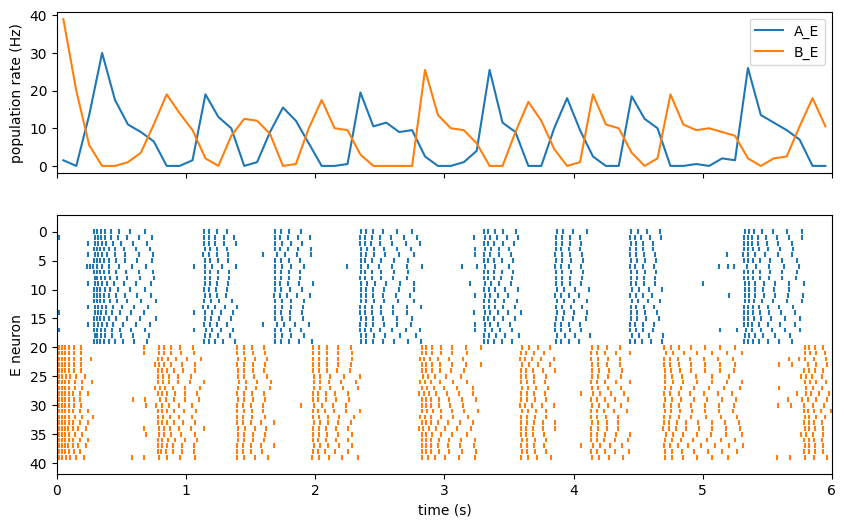

mean rates: A_E = 7.4 Hz,  B_E = 8.0 Hz
correlation between the two pools: -0.69  (negative = anti-phase)
dominant pool changed 16 times in 6 s  ->  period about 0.75 s
synchrony inside pool A_E: 0.85   (1 = all neurons identical)


In [23]:
spikes = run_network()          # run with the default parameters
plot_network(spikes)            # and plot

### 🧠 Question 4

Describe what the network does. (a) Which pool is active when? (b) Roughly how long is one full cycle (A active, then B active, back to A)? (c) What does the correlation between the pools tell you? (d) What is *driving* the rhythm? The input is constant! (e) Look at the raster: do all neurons of a pool fire at exactly the same moments?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The two excitatory pools **take turns**: when A_E fires (about 14 Hz per neuron) B_E is nearly silent (about 1 Hz), then they swap. (The first half second is a start-up transient.)

(b) One full cycle takes about **0.7–1 s** (each pool is dominant for roughly 0.3–0.5 s). The dominant pool changed about 17 times in 6 s with the default random network (`seed=1`) and 12–16 times with other seeds.

(c) The correlation is clearly **negative (about −0.6 to −0.75)**: when one pool's rate is high the other's is low, i.e. the pools are in **anti-phase**.

(d) The rhythm is generated by the **network itself**, not by the input. Reciprocal inhibition makes the pools compete, and the slowly growing adaptation current of the active pool eventually lets the other pool take over (Step 1: adaptation is a slow negative feedback). The drive stays constant throughout.

(e) **No, but nearly.** The neurons of a pool fire in bursts that overlap strongly, but with small timing differences: the synchrony inside the pool is about 0.85, not 1. Each neuron has slightly different drive and adaptation, and a different set of inhibitory inputs.

</details>

### The four knobs (the same function for every experiment)
`explore_network` runs the network and plots it. You only list the parameters you want to change (units: `b0` in pA, `Gbar` in µS, `p` between 0 and 1, `hetero` in %, `w_EE` in mV).

In [24]:
NET_DEFAULTS = dict(b0=500, Gbar=3.0, p=0.75, hetero=3, w_EE=0)


def explore_network(**changes):
    v = dict(NET_DEFAULTS)                # start from the defaults ...
    v.update(changes)                     # ... and replace the ones that were changed
    spikes = run_network(b0=v['b0'] * 1e-12, Gbar=v['Gbar'] * 1e-6, p=v['p'],
                         hetero=v['hetero'] / 100, w_EE=v['w_EE'] * 1e-3)       # convert to SI units
    plot_network(spikes)

### Knob 1: adaptation strength `b0`  (3 min)
**Predict first** what happens at `b0 = 0`, then explore 0, 200, 300, 500 and 800 pA.

In [25]:
interact(explore_network, b0=slider(500, 0, 1000, 50));

interactive(children=(FloatSlider(value=500.0, continuous_update=False, description='b0', max=1000.0, step=50.…

### 🧠 Question 5

(a) What happens at `b0` = 0 (compare with your prediction in Question 3)? (b) What is the smallest `b0` that gives alternation? (c) Above that, how does the **speed** of the rhythm change as you increase `b0`? Why?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) At `b0` = 0 there is **winner-take-all**, as predicted: one pool fires continuously (about 57 Hz) and the other pool is completely silent for the whole run. (Which pool wins depends on the random network.)

(b) At 200 pA there is still a permanent winner. **Alternation starts at about 300 pA**, where it is still slow (only 3 hand-overs in 6 s).

(c) The rhythm gets **faster** as `b0` grows: about 0.7–1 s at 500 pA and about 0.4 s at 800 pA. A larger `b0` makes the adaptation current of the active pool build up faster, so the winner tires sooner and hands over sooner. The pools also fire at lower rates (about 8 Hz at 500 pA, 5.5 Hz at 800 pA).

</details>

### Knob 2: inhibition strength `Gbar`  (3 min)
`Gbar` is the peak conductance of the inhibitory synapses (in µS).

In [26]:
interact(explore_network, Gbar=slider(3.0, 0.0, 6.0, 0.5));

interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='Gbar', max=6.0, step=0.5), …

### 🧠 Question 6

(a) Set `Gbar` = 0. What happens, and why? (b) Now compare `Gbar` = 0.5, 3 and 6 µS. How does the period change? (c) In your own words: what are the **two ingredients** this oscillator needs?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) At `Gbar` = 0 there is **no inhibition, so no competition**: both pools fire **together**, in phase (correlation about +0.97). Ignore the 'dominant pool changed' counter here. Adaptation alone does not make an alternating oscillator: you need the reciprocal inhibition.

(b) With weak inhibition the rhythm is fast (period about 0.6 s at 0.5 µS). It slows down as inhibition gets stronger (about 0.7–1 s at 3 µS), and then changes little (about 0.75 s at 6 µS): once inhibition is strong enough to silence the other pool, making it stronger adds little.

(c) The two ingredients are **reciprocal inhibition** (it creates the competition so that the pools alternate instead of firing together) and a **slow process such as spike-frequency adaptation** (it ends each winner's turn, so that there is no winner-take-all). The constant excitatory drive supplies the energy for both.

</details>

### Knob 3: connection probability `p`
So far every possible connection existed with probability 0.75. What if the network is **sparser**? Try `p` = 1.0, 0.75, 0.5, 0.25 and 0.1. *(Each setting is a different random network, so also try a few runs of the same `p` by changing the slider back and forth: the pattern is reproducible because of the fixed random `seed`.)*

Keep an eye on the **correlation between the pools** printed under the plot.

In [27]:
interact(explore_network, p=slider(0.75, 0.1, 1.0, 0.05));

interactive(children=(FloatSlider(value=0.75, continuous_update=False, description='p', max=1.0, min=0.1, step…

### 🧠 Question 7

(a) How does the correlation between the pools change as `p` goes down from 1.0 to 0.1? (b) Why? Think about what a *sparse* connectivity means for how many inhibitory inputs each E neuron receives (there are only 5 I neurons per pool). (c) If the network had 10 times more neurons, would the same `p` be enough?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) At `p` = 1.0 and 0.75 the pools are cleanly in anti-phase (correlation about −0.6 to −0.75, synchrony inside a pool about 0.85–0.9). At **0.5** they are still in anti-phase (about −0.67), but the switching is faster (period about 0.4–0.6 s) and the neurons of a pool are **less synchronous** (about 0.6). At **0.25** the alternation is lost: the pools fire mostly together (correlation about +0.5 to +0.8) and the synchrony inside a pool collapses (about 0.25). At 0.1 the pools are fully in phase (about +0.97).

(b) With only 5 inhibitory neurons per pool, sparse connectivity means some E neurons receive **no inhibition at all**: the chance that an E neuron has none of its 5 possible inhibitory inputs is only about 0.1 % at `p` = 0.75, but about 3 % at 0.5, 24 % at 0.25 and 59 % at 0.1. The inhibitory neurons also receive fewer E inputs. The inhibition then no longer silences the other pool, so there is no competition (as with `Gbar` = 0). Intermediate `p` leaves each neuron with a *different* set of inputs, so the pool is less uniform.

(c) **Yes, probably even a smaller `p` would do.** What matters is the **number of inhibitory inputs per neuron** (about `p` × number of I neurons), not `p` itself. With ten times more neurons, the same `p` gives ten times more inputs per neuron, so very few E neurons would be left without inhibition. (You can test this by changing `n_E` and `n_I` in `run_network`.)

</details>

### Knob 4: heterogeneity `hetero`
`hetero` is the random spread (in %) of the drive, `b0` and `tauW` between neurons. **Predict first:** does the oscillator *need* the neurons to be different? Test `hetero` = 0, 3, 20 and 40 %, and look at both the plot and the **synchrony** inside pool A_E.

In [15]:
interact(explore_network, hetero=slider(3, 0, 40, 1));

interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='hetero', max=40.0, step=1.0…

### 🧠 Question 8

(a) Does the rhythm survive with **no** heterogeneity (`hetero` = 0)? What does the raster look like? (b) What happens with a **large** spread (40 %)? (c) So what role does heterogeneity play: is it needed for the oscillation, harmless, or harmful?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) **Yes, the rhythm survives.** Even at `hetero` = 0 the neurons are not identical: they start at random voltages and have random connections. The oscillation is a little faster (period about 0.5–0.6 s instead of 0.7–1 s) and the pool is slightly more synchronous (about 0.9 instead of 0.85), so the raster shows neurons firing almost in unison.

(b) With 40 % spread the rhythm becomes **slow, irregular and uneven**: the period gets long (about 2.4–3 s) and one pool can dominate much more than the other (in one run about 2.5 Hz vs 12.7 Hz), because the random draw makes one pool stronger overall (more drive, less adaptation). Some neurons are so weakly driven that they hardly fire, so the neurons in a pool no longer share the same pattern.

(c) Heterogeneity is **not needed** for the oscillation. Moderate amounts (up to about 20 %) are **harmless**: the period lengthens a little and the neurons spread out in time. Large amounts become **harmful**: they make the pools unequal and the rhythm slow and irregular. In real circuits heterogeneity is unavoidable, so a robust oscillator must tolerate it, and this one does.

</details>

### 🟡 Optional: recurrent excitation `w_EE`
You asked whether the E neurons excite each other. In the basic network they do not (`w_EE = 0`). Setting `w_EE` > 0 adds **delta synapses between the E neurons of the same pool** (connection probability `p`). Try 0, 2, 4 and 8 mV.

In [16]:
interact(explore_network, w_EE=slider(0, 0, 10, 1));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='w_EE', max=10.0, step=1.0),…

### 🧠 Question 9

🟡 *Optional.* What does recurrent excitation do to (a) the synchrony inside a pool, (b) the firing rates, (c) the speed and cleanness of the alternation? Why might a real half-centre oscillator include it?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a)-(c) Recurrent excitation makes the neurons of a pool excite each other, a **positive feedback**. At `w_EE` = 2 mV the alternation is a little faster and less clean (anti-phase correlation about −0.56 instead of −0.7). At **4 mV** the synchrony inside a pool rises to about 0.97, the pools fire harder (about 11 Hz instead of 8 Hz), the alternation is **much faster** (period about 0.35 s) and **less clean** (correlation about −0.45). At **8 mV** the positive feedback **runs away**: both pools fire at 75–100 Hz and the rhythm is destroyed, because the recurrent excitation overwhelms the inhibition and the adaptation. A real half-centre oscillator can use some recurrent excitation to make each burst stronger and more synchronous once it starts, but the balance with inhibition and adaptation must be right.

</details>

---
# Step 3: Record the activity and replay it

Watching a simulation is easier if we do not have to re-run it every time. We build a small tool that works in two stages:

1. **Record:** go through the simulation in small time steps and *store*, for every neuron, how fast it fired in the last 100 ms. This is the **recording**: a table with one row per moment and one column per neuron. It can be **saved to a file** and loaded again later, with no need to re-run MOOSE.
2. **Replay:** turn the recording into a **movie** (one picture per time step) and play it back with a ▶ **play button**.

In the movie every neuron is a coloured dot: **circles = excitatory (E), squares = inhibitory (I)**, pool A on the left and pool B on the right; **grey = silent, yellow → red = firing faster**. Below the map, the population rates with a cursor at the current time.

### The layout and the recording

In [28]:
# ---- where each neuron sits on the map ----
def grid(n, x0, y0, columns):
    return [(x0 + i % columns, y0 + i // columns) for i in range(n)]

ORDER = ['A_E', 'B_E', 'A_I', 'B_I']                                   # the order of the neurons in a recording
POSITIONS = {'A_E': grid(20, 0, 2, 5), 'A_I': grid(5, 0, 0, 5),        # pool A (left): 20 E on top, 5 I below
             'B_E': grid(20, 7, 2, 5), 'B_I': grid(5, 7, 0, 5)}        # pool B (right)
colormap = plt.cm.YlOrRd                                               # pale yellow = slow, dark red = fast
MAX_RATE = 40                                                          # Hz that maps to the darkest red
GREY = (0.83, 0.83, 0.83, 1.0)                                         # colour of a silent neuron


# ---- RECORD: the activity of every neuron at every time step ----
def record_activity(spikes, T=6.0, step_ms=50, window_ms=100):
    '''For every time step: how fast did each neuron fire during the last `window_ms`?'''
    times = np.arange(0, T, step_ms / 1000)
    window = window_ms / 1000
    rates = []                                                         # one row per time step, one column per neuron
    for t in times:
        row = []
        for name in ORDER:
            for s in spikes[name]:
                n_recent = np.searchsorted(s, t, side='right') - np.searchsorted(s, t - window, side='right')
                row.append(n_recent / window)                          # spikes in the window -> Hz
        rates.append(row)
    centers, rate_A = population_rate(spikes['A_E'], T)
    centers, rate_B = population_rate(spikes['B_E'], T)
    return dict(times=times, rates=np.array(rates), pop_t=centers, pop_A=rate_A, pop_B=rate_B, window_ms=window_ms)


# ---- SAVE and LOAD a recording (so it can be replayed later without MOOSE) ----
def save_recording(rec, filename='hco_recording.npz'):
    np.savez(filename, **rec)


def load_recording(filename='hco_recording.npz'):
    data = np.load(filename)
    return {key: data[key] for key in data.files}

### The replay
`make_movie` draws the map once and then, for each time step, only **changes the colours** and the cursor, saving each picture as a PNG image in memory. `play_movie` shows the pictures one after another when you press ▶ (the slider lets you jump to any moment).

In [29]:
def make_movie(rec):
    '''Turn a recording into a list of images (one PNG per time step).'''
    xs = [x for name in ORDER for (x, y) in POSITIONS[name]]
    ys = [y for name in ORDER for (x, y) in POSITIONS[name]]
    n_E = len(POSITIONS['A_E']) + len(POSITIONS['B_E'])                # the first 40 neurons are excitatory

    fig = plt.figure(figsize=(9, 6.5))
    ax_map = fig.add_axes([0.05, 0.32, 0.9, 0.62])
    ax_rate = fig.add_axes([0.08, 0.07, 0.84, 0.18])

    # the map (drawn once)
    circles = ax_map.scatter(xs[:n_E], ys[:n_E], s=450, marker='o', edgecolors='gray', linewidths=1.5)
    squares = ax_map.scatter(xs[n_E:], ys[n_E:], s=300, marker='s', edgecolors='gray', linewidths=1.5)
    ax_map.text(2, 6.0, 'POOL A', ha='center', fontsize=14, color='tab:blue')
    ax_map.text(9, 6.0, 'POOL B', ha='center', fontsize=14, color='tab:orange')
    ax_map.set_xlim(-1, 12)
    ax_map.set_ylim(-1, 6.8)
    ax_map.set_aspect('equal')
    ax_map.axis('off')
    title = ax_map.set_title('')

    # the population rates with a cursor (drawn once)
    ax_rate.plot(rec['pop_t'], rec['pop_A'], color='tab:blue', label='A_E')
    ax_rate.plot(rec['pop_t'], rec['pop_B'], color='tab:orange', label='B_E')
    cursor = ax_rate.axvline(0, color='k')
    ax_rate.set_xlim(0, rec['times'][-1])
    ax_rate.set_xlabel('time (s)')
    ax_rate.set_ylabel('rate (Hz)')
    ax_rate.legend(loc='upper right', ncol=2, fontsize=8)

    # one picture per time step: only the colours and the cursor change
    frames = []
    for t, rates in zip(rec['times'], rec['rates']):
        colors = [GREY if r == 0 else colormap(0.2 + 0.8 * min(r / MAX_RATE, 1.0)) for r in rates]
        circles.set_facecolor(colors[:n_E])
        squares.set_facecolor(colors[n_E:])
        cursor.set_xdata([t, t])
        title.set_text(f't = {t:.2f} s    (grey = silent in the last {int(rec["window_ms"])} ms, red = {MAX_RATE} Hz or more)')
        buffer = io.BytesIO()
        fig.savefig(buffer, format='png', dpi=70)
        frames.append(buffer.getvalue())
    plt.close(fig)
    return frames


def play_movie(frames):
    '''Show the movie with a play button and a slider.'''
    image = widgets.Image(value=frames[0], format='png')
    slider_ = widgets.IntSlider(value=0, min=0, max=len(frames) - 1, description='frame',
                                layout=widgets.Layout(width='500px'))
    play = widgets.Play(value=0, min=0, max=len(frames) - 1, step=1, interval=60)   # 60 ms per picture
    widgets.jslink((play, 'value'), (slider_, 'value'))                              # play moves the slider
    slider_.observe(lambda change: setattr(image, 'value', frames[change['new']]), names='value')
    display(widgets.VBox([widgets.HBox([play, slider_]), image]))

### Record it and press ▶ (2 min)
Recording and making the movie takes a few seconds. After that, **replaying costs nothing**: press ▶ as often as you like.

In [30]:
rec = record_activity(spikes)        # RECORD the simulation you ran above
frames = make_movie(rec)             # turn the recording into a movie
play_movie(frames)                   # REPLAY it: press the play button!

### 🧠 Question 10

Press ▶ and watch a few cycles (or drag the slider across a switch between the pools). (a) While pool A is dominant, what are A_E, A_I, B_I and B_E each doing? (b) Do all the neurons of a pool stop at the same instant? What does that tell you about how a switch happens?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) While pool A is dominant: the **A_E circles are coloured** (about 14 Hz each); the **A_I squares are the reddest of all** (about 27 Hz), because each of them is excited by many A_E neurons; the **B_I squares are grey** (below 1 Hz: they are excited only by B_E, which is quiet); and the **B_E circles are mostly grey** (about 1 Hz), held down by the inhibition from A_I. When pool B is dominant the picture is the mirror image.

(b) **No.** In this simulation the neurons of the pool that is giving way go quiet over a spread of roughly 0.1–0.4 s, and the neurons of the other pool do not start all at once either: a few start first and the rest follow. A switch is therefore a fast but gradual **recruitment**, not an instantaneous flip. Small differences between neurons (their drive, their random connections and their individual adaptation state) decide who leads.

</details>

### 🟡 Optional: save the recording and replay it later
The recording is just a small table of numbers, so it can be saved to a file. In a new session (even without MOOSE installed) you only need the functions above plus these lines. Try also a **shorter window** (20 ms): you will see individual spikes instead of averaged activity. Finally, the movie can be exported as an animated GIF.

In [ ]:
save_recording(rec, 'hco_recording.npz')                 # save the recording to a file

rec_loaded = load_recording('hco_recording.npz')         # ... later: load it again ...
play_movie(make_movie(rec_loaded))                       # ... and replay it, no simulation needed

# a shorter window shows individual spikes:
# play_movie(make_movie(record_activity(spikes, window_ms=20)))

# export as an animated GIF (needs the Pillow package, which comes with matplotlib):
# from PIL import Image
# pictures = [Image.open(io.BytesIO(f)) for f in frames]
# pictures[0].save('hco_movie.gif', save_all=True, append_images=pictures[1:], duration=60, loop=0)

---
# Summary

| Concept | What you saw |
|---|---|
| **LIF** | hard threshold and reset; constant input gives a **constant** rate |
| **AdExIF** | exponential spike upstroke + adaptation current `w` (`b0` per spike, decays with `tauW`): the rate **falls** during a constant input |
| **Half-centre oscillator** | two pools that inhibit each other take turns, driven by a **constant** input |
| **Adaptation `b0`** | the slow process that ends each winner's turn: without it, winner-take-all; stronger means a faster rhythm |
| **Inhibition `Gbar`** | creates the competition: without it both pools fire together; stronger means a slower rhythm |
| **Connection probability `p`** | sets *how many* inhibitory inputs each neuron gets: too sparse and the pools stop competing |
| **Heterogeneity `hetero`** | not needed for the rhythm; moderate amounts are harmless, large amounts make it irregular and uneven |
| **Recurrent excitation `w_EE`** (optional) | makes a pool more synchronous and the bursts self-reinforcing |
| **Record and replay** | store the activity once, then replay it as often as you like, even from a file |